In [13]:
# Cell 1: Import necessary libraries
import os
import cv2
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.model_selection import train_test_split
import tf2onnx
import onnx
import random
from tqdm import tqdm

In [14]:
# Cell 2: Set paths and directories

IMAGE_FOLDER_PROVIDEDIMAGES = r"C:\Users\beren\Documents\paparazzi\playground\provided_images"
IMAGE_FOLDER_VIDEOCAPSIMULATIONROUND1 = r"C:\Users\beren\Documents\paparazzi\playground\videocap_simulation_round1"
IMAGE_FOLDER_TESTROUND2 = r"C:\Users\beren\Documents\paparazzi\playground\videocap_testround2"

LABELS_JSON_PROVIDEDIMAGES = r"C:\Users\beren\Documents\paparazzi\playground\labelled_provided_images\results.json"
LABELS_JSON_VIDEOCAPSIMULATIONROUND1 = r"C:\Users\beren\Documents\paparazzi\playground\labelled_videocap_simulation_round1\results.json"
LABELS_JSON_TESTROUND2 = r"C:\Users\beren\Documents\paparazzi\playground\labelled_videocap_testround2\results.json"

OUTPUT_FOLDER = r"C:\Users\beren\Documents\paparazzi\playground\CNN_Output"
VIDEO_OUTPUT =  r"C:\Users\beren\Documents\paparazzi\playground\CNN_Video"
TEXT_OUTPUT =  r"C:\Users\beren\Documents\paparazzi\playground\CNN_Text"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

In [15]:
# Cell 3: Load labels from JSON file
labels_data = {}

with open(LABELS_JSON_PROVIDEDIMAGES, "r") as f:
    data = json.load(f)
    labels_data["provided_images"] = data
with open(LABELS_JSON_VIDEOCAPSIMULATIONROUND1, "r") as f:
    data = json.load(f)
    labels_data["videocap_simulation_round1"] = data
with open(LABELS_JSON_TESTROUND2, "r") as f:
    data = json.load(f)
    labels_data["test_round2"] = data

In [16]:
# Cell 4: Load images and labels
def load_data(image_folder, labels, img_size=(520, 240)):
    images, label_grids = [], []
    for i, (filename, data) in enumerate(labels.items()):
        img_path = os.path.join(image_folder, f"{filename}.jpg")
        if not os.path.exists(img_path):
            continue

        # Read the image and convert from BGR to YUV
        img = cv2.imread(img_path)
        images.append(img)

        ## Save the YUV grid of the first image to a text file
        # if i == 0:
        #     yuv_output_path = os.path.join(TEXT_OUTPUT, "first_image_yuv_grid.txt")
        #     with open(yuv_output_path, "w") as f:
        #         f.write(f"{img_yuv.tolist()}\n")
        #     print(f"YUV image grid of the first image saved to {yuv_output_path}")

        # Get the label grid and append it
        label_grid = np.array(data["scores"])
        label_grids.append(label_grid)

    return np.array(images), np.array(label_grids)

# Use the appropriate sub-dictionaries from labels_data
X_VIDEOCAPSIMULATIONROUND1, y_VIDEOCAPSIMULATIONROUND1 = load_data(
    IMAGE_FOLDER_VIDEOCAPSIMULATIONROUND1, labels_data["videocap_simulation_round1"]
)
y_VIDEOCAPSIMULATIONROUND1 = np.expand_dims(y_VIDEOCAPSIMULATIONROUND1, axis=-1)

X_TESTROUND2, y_TESTROUND2 = load_data(
    IMAGE_FOLDER_TESTROUND2, labels_data["test_round2"]
)
y_TESTROUND2 = np.expand_dims(y_TESTROUND2, axis=-1)

X_PROVIDEDIMAGES, y_PROVIDEDIMAGES = load_data(
    IMAGE_FOLDER_PROVIDEDIMAGES, labels_data["provided_images"]
)
y_PROVIDEDIMAGES = np.expand_dims(y_PROVIDEDIMAGES, axis=-1)

# Concatenate all datasets into X_train and y_train
X_TRAIN = np.concatenate([X_VIDEOCAPSIMULATIONROUND1, X_TESTROUND2], axis=0)
y_TRAIN = np.concatenate([y_VIDEOCAPSIMULATIONROUND1, y_TESTROUND2], axis=0)

X_TEST = X_PROVIDEDIMAGES
y_TEST = y_PROVIDEDIMAGES

In [27]:
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import regularizers, layers, models
import tensorflow as tf
import numpy as np
from tqdm import tqdm
from tensorflow.keras.backend import int_shape


# Your original build model function with hyperparameters
def build_model(learning_rate=1e-4, dropout_rate=0.5, l2_reg=1e-3): 
    reg = regularizers.l2(l2_reg)

    model = models.Sequential([
        layers.Conv2D(
            filters=3,
            kernel_size=(3, 3),
            strides=(8, 8),
            padding='same',
            activation='relu',
            kernel_regularizer=reg,
            input_shape=(240, 520, 3),
        ),
        layers.Conv2D(
            filters=2,
            kernel_size=(3, 3),
            strides=(2, 2),
            padding='same',
            activation='relu',
            kernel_regularizer=reg,
        ),
        layers.Flatten(),
        layers.Dense(8, activation='relu', kernel_regularizer=reg),
        layers.Dropout(dropout_rate),
        layers.Dense(96, activation='sigmoid'),
        layers.Reshape((6, 16, 1))
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

# MAC calculation
def calculate_mac(model):
    """
    Correctly compute approximate MACs for Conv2D/Dense.
    Skips the batch dimension (None) but uses spatial dims + channels.
    """
    total_mac = 0
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            in_shape = int_shape(layer.input)    # (None, H_in, W_in, C_in)
            out_shape = int_shape(layer.output)  # (None, H_out, W_out, C_out)
            # Unpack ignoring the batch dimension:
            _, inH, inW, inC = in_shape
            _, outH, outW, outC = out_shape

            # If anything is None, skip
            if any(dim is None for dim in [inH, inW, inC, outH, outW, outC]):
                continue

            kH, kW = layer.kernel_size
            # MAC = (outH * outW * outC) * (kH * kW * inC)
            mac = outH * outW * outC * kH * kW * inC
            total_mac += mac

        elif isinstance(layer, layers.Dense):
            in_units = int_shape(layer.input)[-1]
            out_units = layer.units
            if in_units is None or out_units is None:
                continue
            # MAC = in_units * out_units
            mac = in_units * out_units
            total_mac += mac

    return total_mac

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

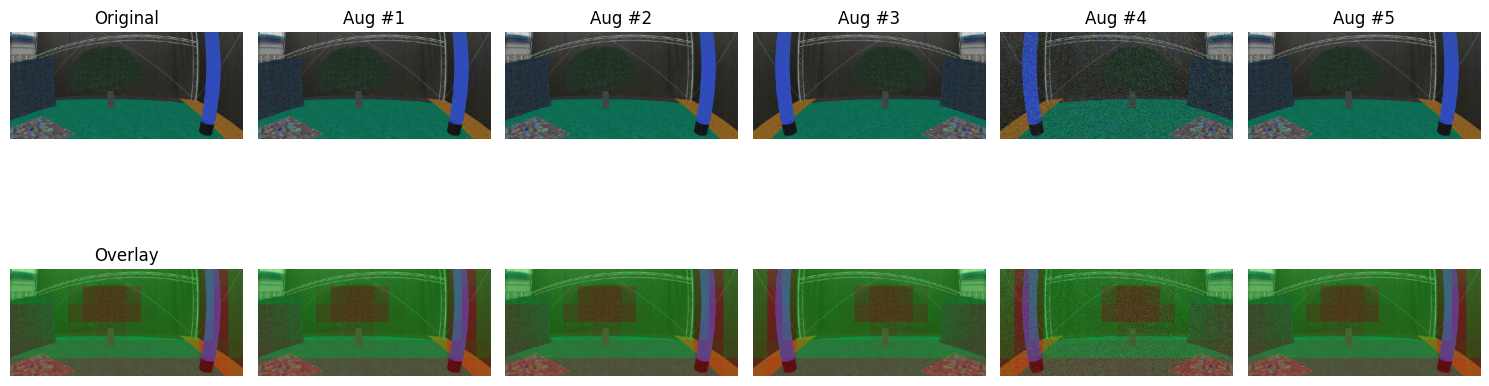

In [18]:

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

def rotate_image_tf(image, angle):
    """
    Rotate an image by a given angle (in radians) using tf.raw_ops.ImageProjectiveTransformV3.
    """
    h = tf.cast(tf.shape(image)[0], tf.float32)
    w = tf.cast(tf.shape(image)[1], tf.float32)
    cx = w / 2.0
    cy = h / 2.0
    cos_val = tf.cos(angle)
    sin_val = tf.sin(angle)
    a = cos_val
    b = -sin_val
    c = cx - cos_val * cx + sin_val * cy
    d = sin_val
    e = cos_val
    f = cy - sin_val * cx - cos_val * cy
    transform = [a, b, c, d, e, f, 0.0, 0.0]
    image_batch = tf.expand_dims(image, 0)
    transforms = tf.convert_to_tensor([transform], dtype=tf.float32)
    output_shape = tf.convert_to_tensor([tf.shape(image)[0], tf.shape(image)[1]], dtype=tf.int32)
    transformed = tf.raw_ops.ImageProjectiveTransformV3(
        images=image_batch,
        transforms=transforms,
        output_shape=output_shape,
        interpolation="BILINEAR",
        fill_value=0
    )
    return tf.squeeze(transformed, axis=0)

def gaussian_blur_tf(image, sigma):
    """
    Apply Gaussian blur using depthwise convolution.
    """
    kernel_size = tf.cast(2 * tf.math.ceil(2 * sigma) + 1, tf.int32)
    x = tf.range(-kernel_size//2 + 1, kernel_size//2 + 1, dtype=tf.float32)
    gauss = tf.exp(- (x**2) / (2.0 * sigma**2))
    gauss /= tf.reduce_sum(gauss)
    gauss = tf.reshape(gauss, [kernel_size, 1])
    kernel = gauss * tf.transpose(gauss)
    kernel = kernel[:, :, tf.newaxis, tf.newaxis]
    channels = tf.shape(image)[-1]
    kernel = tf.tile(kernel, [1, 1, channels, 1])
    image = tf.expand_dims(image, axis=0)
    blurred = tf.nn.depthwise_conv2d(image, kernel, strides=[1, 1, 1, 1], padding='SAME')
    return tf.squeeze(blurred, axis=0)

@tf.function
def zoom_fn(image):
    """
    Apply zoom augmentation to an image.
    """
    zoom_factor = tf.random.uniform([], 0.7, 1.3)
    orig_shape = tf.shape(image)[:2]
    new_size = tf.cast(tf.cast(orig_shape, tf.float32) * zoom_factor, tf.int32)
    image_resized = tf.image.resize(image, new_size)
    
    def zoom_in():
        offset = (new_size - orig_shape) // 2
        return tf.image.crop_to_bounding_box(image_resized, offset[0], offset[1],
                                             orig_shape[0], orig_shape[1])
    
    def zoom_out():
        pad_total = orig_shape - new_size
        pad_before = pad_total // 2
        pad_after = pad_total - pad_before
        padded = tf.pad(image_resized, [[pad_before[0], pad_after[0]],
                                        [pad_before[1], pad_after[1]], [0, 0]], mode='CONSTANT')
        return tf.image.resize_with_crop_or_pad(padded, orig_shape[0], orig_shape[1])
    
    return tf.cond(zoom_factor > 1.0, zoom_in, zoom_out)

@tf.function
def augment_single_image(image, label):
    """
    GPU-friendly augmentation for a single image.
    Applies rotation, flipping (with label flip), zoom, photometric adjustments, blur, noise, and color shifts.
    Finally converts the image from RGB to YUV.
    """
    image = tf.image.convert_image_dtype(image, tf.float32)
    
    def augment_body():
        local_image = image
        local_label = label
        # Horizontal flip with 50% chance (flip both image and label)
        do_flip = tf.less(tf.random.uniform([]), 0.5)
        local_image = tf.cond(do_flip, lambda: tf.image.flip_left_right(local_image), lambda: local_image)
        local_label = tf.cond(do_flip, lambda: tf.image.flip_left_right(local_label), lambda: local_label)
        # Photometric adjustments (each applied with 20% chance)
        brightness_delta = tf.random.uniform([], -0.3, 0.3)
        local_image = tf.cond(
            tf.random.uniform([]) < 0.2,
            lambda: tf.clip_by_value(tf.image.adjust_brightness(local_image, brightness_delta), 0.0, 1.0),
            lambda: local_image
        )
        
        contrast_factor = tf.random.uniform([], 0.7, 1.3)
        local_image = tf.cond(
            tf.random.uniform([]) < 0.2,
            lambda: tf.clip_by_value(tf.image.adjust_contrast(local_image, contrast_factor), 0.0, 1.0),
            lambda: local_image
        )
        
        gamma_factor = tf.random.uniform([], 0.7, 1.3)
        local_image = tf.cond(
            tf.random.uniform([]) < 0.2,
            lambda: tf.clip_by_value(tf.image.adjust_gamma(local_image, gamma_factor), 0.0, 1.0),
            lambda: local_image
        )

        # Blurring (5% chance)
        local_image = tf.cond(tf.random.uniform([]) < 0.05,
                              lambda: gaussian_blur_tf(local_image, tf.random.uniform([], 1.0, 2.0)),
                              lambda: local_image)
        # Random noise (20% chance)
        local_image = tf.cond(tf.random.uniform([]) < 0.2,
                              lambda: tf.cond(tf.random.uniform([]) < 0.5,
                                              lambda: tf.clip_by_value(local_image +
                                                            tf.random.normal(tf.shape(local_image), 0.0, 0.1), 0.0, 1.0),
                                              lambda: tf.where(tf.expand_dims(tf.less(tf.random.uniform(tf.shape(local_image)[:2]), 0.03), -1),
                                                               1.0, local_image)),
                              lambda: local_image)
        # Color augmentations (30% chance each)
        local_image = tf.cond(tf.random.uniform([]) < 0.30,
                              lambda: tf.image.adjust_hue(local_image, tf.random.uniform([], -0.2, 0.2)),
                              lambda: local_image)
        local_image = tf.cond(tf.random.uniform([]) < 0.30,
                              lambda: tf.image.adjust_saturation(local_image, tf.random.uniform([], 0.7, 1.3)),
                              lambda: local_image)
        return local_image, local_label

    image, label = tf.cond(tf.random.uniform([]) < 0.2,
                           lambda: (image, label),
                           lambda: augment_body())
    image = tf.clip_by_value(image, 0.0, 1.0)
    return tf.image.rgb_to_yuv(image), label

def create_augmented_dataset(x, y, batch_size=32, shuffle_buffer=1000, augment=True):
    """
    Create a tf.data.Dataset that applies augmentation (or simply converts to YUV),
    then forces each image to be resized to the fixed original shape and reshapes labels.
    """
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle_buffer > 0:
        dataset = dataset.shuffle(shuffle_buffer, reshuffle_each_iteration=True)
    if augment:
        dataset = dataset.map(augment_single_image, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        dataset = dataset.map(lambda img, lbl: (tf.image.rgb_to_yuv(
                                tf.image.convert_image_dtype(img, tf.float32)), lbl),
                              num_parallel_calls=tf.data.AUTOTUNE)
    # Enforce fixed image shape (e.g. [240,520,3]) and reshape labels to (6,16,1)
    fixed_shape = x.shape[1:]  # e.g. (240,520,3)
    dataset = dataset.map(lambda img, lbl: (tf.image.resize(img, [fixed_shape[0], fixed_shape[1]]),
                                              tf.reshape(lbl, (6,16,1))),
                          num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def show_augmentations_tf(original_image, original_label, n_samples=5):
    """
    Visualize multiple random augmentations for a single image with corresponding labels.
    Displays two rows:
      - Top row: Augmented images.
      - Bottom row: Same images with a semi-transparent overlay of labels.
        The overlay colors interpolate between red (0) and green (1),
        so a value of 0.5 yields a blend (e.g., half red, half green).
    """
    image_rgb = tf.image.convert_image_dtype(original_image, tf.float32)
    H, W = image_rgb.shape[:2]
    
    plt.figure(figsize=(15, 6))
    # First column: Original image & its label overlay.
    ax = plt.subplot(2, n_samples+1, 1)
    ax.imshow(image_rgb.numpy())
    ax.set_title('Original')
    ax.axis('off')
    
    ax = plt.subplot(2, n_samples+1, n_samples+2)
    ax.imshow(image_rgb.numpy())
    overlay = tf.image.resize(original_label, [H, W], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    # Create color overlay: red for 0, green for 1 (linear interpolation)
    color_overlay = tf.concat([1 - overlay, overlay, tf.zeros_like(overlay)], axis=-1)
    ax.imshow(color_overlay.numpy(), alpha=0.3)
    ax.set_title('Overlay')
    ax.axis('off')
    
    # Augmentations.
    for i in range(n_samples):
        aug_img, aug_lbl = augment_single_image(original_image, original_label)
        aug_img_rgb = tf.image.yuv_to_rgb(aug_img)
        
        # Top row: Augmented image.
        ax = plt.subplot(2, n_samples+1, i+2)
        ax.imshow(aug_img_rgb.numpy())
        ax.set_title(f'Aug #{i+1}')
        ax.axis('off')
        
        # Bottom row: Augmented image with label overlay.
        ax = plt.subplot(2, n_samples+1, n_samples + i + 3)
        ax.imshow(aug_img_rgb.numpy())
        overlay = tf.image.resize(aug_lbl, [H, W], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
        color_overlay = tf.concat([1 - overlay, overlay, tf.zeros_like(overlay)], axis=-1)
        ax.imshow(color_overlay.numpy(), alpha=0.3)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage for visualization (ensure X_TRAIN and Y_TRAIN are defined with proper data)
sample_image = X_TRAIN[530]
sample_label = y_TRAIN[530]  # expected to be a grid of shape (16,6) or (6,16)
sample_label = tf.reshape(sample_label, (6,16,1))  # adjust shape if necessary
show_augmentations_tf(sample_image, sample_label)


In [19]:
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid
import tensorflow as tf
import pickle

def train_with_augmentation(model, x_train, y_train, x_val, y_val, 
                            max_epochs, batch_size, patience):
    """
    Train the model using a tf.data pipeline for on-the-fly augmentation,
    early stopping, and GPU support.
    """
    device = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
    print("GPU found, using GPU." if device == '/GPU:0' else "No GPU found, running on CPU.")
    
    train_ds = create_augmented_dataset(x_train, y_train, batch_size=batch_size, 
                                        shuffle_buffer=2000, augment=True)
    val_ds = create_augmented_dataset(x_val, y_val, batch_size=batch_size, 
                                      shuffle_buffer=0, augment=False)
    
    history = {'loss': [], 'mae': [], 'val_loss': [], 'val_mae': []}
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    pbar = tqdm(range(max_epochs), desc="Epochs", unit="epoch")
    
    with tf.device(device):
        for epoch in pbar:
            pbar.set_description(f"Epoch {epoch+1} - Augmenting & Training")
            hist = model.fit(train_ds, validation_data=val_ds, epochs=1, verbose=1)
            train_loss = hist.history['loss'][0]
            train_mae  = hist.history['mae'][0]
            val_loss   = hist.history['val_loss'][0]
            val_mae    = hist.history['val_mae'][0]
            
            history['loss'].append(train_loss)
            history['mae'].append(train_mae)
            history['val_loss'].append(val_loss)
            history['val_mae'].append(val_mae)
            
            pbar.set_postfix({
                'Phase': 'Training',
                'Train Loss': f"{train_loss:.4f}",
                'Train MAE': f"{train_mae:.4f}",
                'Val Loss': f"{val_loss:.4f}",
                'Val MAE': f"{val_mae:.4f}"
            })
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= patience:
                    print(f"Early stopping at epoch {epoch+1} after {patience} epochs with no improvement.")
                    break
    return history

param_grid = {
    'learning_rate': [1e-4, 1e-5],
    'dropout_rate': [0.3, 0.5],
    'l2_reg': [1e-3, 1e-4]
}

best_model = None
best_history = None
best_params = None
best_val_loss = float('inf')

for params in ParameterGrid(param_grid):
    print(f"Training with params: {params}")
    model_new = build_model(learning_rate=params['learning_rate'], 
                            dropout_rate=params['dropout_rate'], 
                            l2_reg=params['l2_reg'])
    history = train_with_augmentation(model_new, X_TRAIN, y_TRAIN, X_TEST, y_TEST,
                                      max_epochs=300, batch_size=64, patience=5)
    
    if min(history['val_loss']) < best_val_loss:
        best_val_loss = min(history['val_loss'])
        best_model = model_new
        best_history = history
        best_params = params

# Save best parameters
with open("best_params.pkl", "wb") as f:
    pickle.dump(best_params, f)

print(f"Best validation loss: {best_val_loss}")
print(f"Best parameters: {best_params}")


Training with params: {'dropout_rate': 0.3, 'l2_reg': 0.001, 'learning_rate': 0.0001}
No GPU found, running on CPU.


Epoch 1 - Augmenting & Training:   0%|          | 0/300 [00:00<?, ?epoch/s]

57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 158ms/step - loss: 0.5660 - mae: 0.3737 - val_loss: 0.5500 - val_mae: 0.3880


Epoch 2 - Augmenting & Training:   0%|          | 1/300 [00:12<1:01:44, 12.39s/epoch, Phase=Training, Train Loss=0.5675, Train MAE=0.3788, Val Loss=0.5500, Val MAE=0.3880]

57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 0.5603 - mae: 0.3752 - val_loss: 0.5470 - val_mae: 0.3892


...

57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - loss: 0.4998 - mae: 0.4078 - val_loss: 0.4642 - val_mae: 0.4217


Epoch 9 - Augmenting & Training:   3%|▎         | 8/300 [01:15<44:24,  9.13s/epoch, Phase=Training, Train Loss=0.4906, Train MAE=0.4129, Val Loss=0.4642, Val MAE=0.4217]

26/57 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - loss: 0.4611 - mae: 0.4052

Epoch 9 - Augmenting & Training:   3%|▎         | 8/300 [01:19<48:39, 10.00s/epoch, Phase=Training, Train Loss=0.4906, Train MAE=0.4129, Val Loss=0.4642, Val MAE=0.4217]


KeyboardInterrupt: 

Validation Evaluation:
loss: 0.1647
compile_metrics: 0.2401


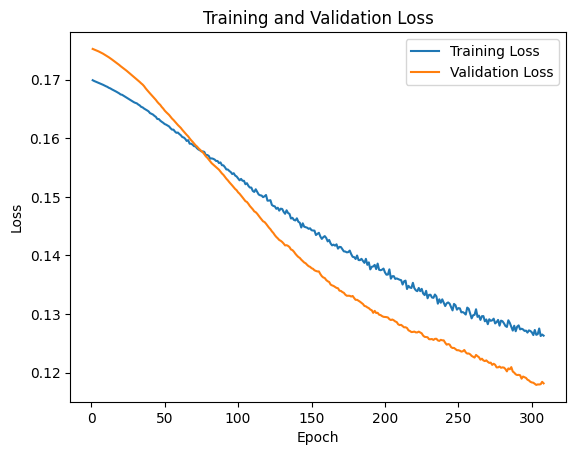

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


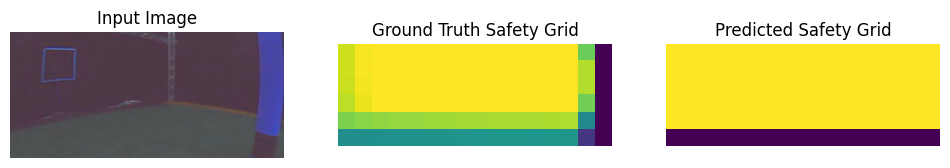

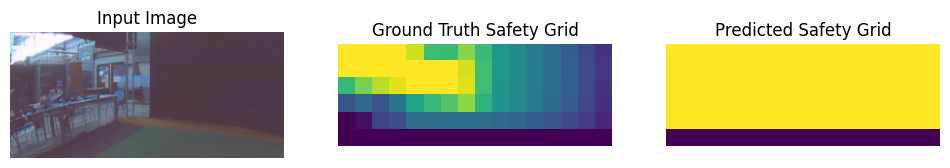

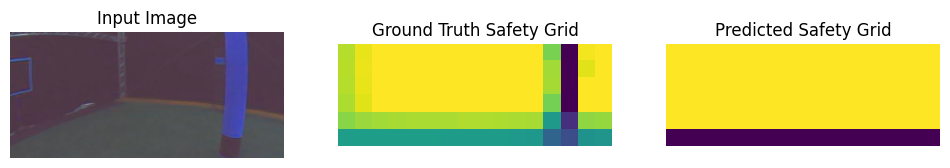

In [ ]:
# Evaluation

import matplotlib.pyplot as plt
import random
import numpy as np
import tensorflow as tf

def evaluate_training(model, history, x_val, y_val, num_samples=3):
    """
    Evaluate the trained model and plot relevant metrics and predictions.
    
    Args:
        model: Trained Keras model.
        history: Dictionary with training history (loss, val_loss, etc.).
        x_val, y_val: Validation data.
        num_samples: Number of random samples to visualize.
    
    Displays:
        - Model evaluation metrics.
        - Plot of training and validation loss over epochs.
        - Sample input image with its ground truth and predicted safety grid.
    """
    # Evaluate the model on the validation set.
    eval_results = model.evaluate(x_val, y_val, verbose=0)
    print("Validation Evaluation:")
    if isinstance(eval_results, list):
        for name, value in zip(model.metrics_names, eval_results):
            print(f"{name}: {value:.4f}")
    else:
        print(f"Loss: {eval_results:.4f}")
    
    # Plot training vs validation loss.
    epochs = range(1, len(history['loss']) + 1)
    plt.figure()
    plt.plot(epochs, history['loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.show()
    
    # Get predictions on the validation set.
    preds = model.predict(x_val)
    
    # Visualize a few random samples.
    sample_indices = random.sample(range(len(x_val)), num_samples)
    for i in sample_indices:
        plt.figure(figsize=(12, 4))
        
        # Input image display (if applicable).
        if len(x_val[i].shape) == 2 or (len(x_val[i].shape) == 3 and x_val[i].shape[-1] == 1):
            plt.subplot(1, 3, 1)
            plt.imshow(x_val[i].squeeze(), cmap='gray')
        else:
            plt.subplot(1, 3, 1)
            plt.imshow(x_val[i])
        plt.title("Input Image")
        plt.axis('off')
        
        # Ground truth safety grid.
        plt.subplot(1, 3, 2)
        plt.imshow(y_val[i].squeeze(), cmap='viridis', vmin=0, vmax=1)
        plt.title("Ground Truth Safety Grid")
        plt.axis('off')
        
        # Predicted safety grid.
        plt.subplot(1, 3, 3)
        plt.imshow(preds[i].squeeze(), cmap='viridis', vmin=0, vmax=1)
        plt.title("Predicted Safety Grid")
        plt.axis('off')
        
        plt.show()

# Function call (for the next notebook cell):
evaluation_results = evaluate_training(best_model, history, X_TEST, y_TEST, num_samples=3)


In [29]:
# Cell 12: Save and convert the model to ONNX format

best_model.output_names=['output']

# Save the Keras model
best_model.save(r"C:\Users\beren\Documents\paparazzi\playground\cnn_model.keras")

# Convert the trained model to ONNX format
onnx_model_path = r"C:\Users\beren\Documents\paparazzi\playground\cnn_model.onnx"
onnx_model, _ = tf2onnx.convert.from_keras(
    best_model,
    opset=13,
    input_signature=[tf.TensorSpec(shape=[None, 240, 520, 3], dtype=tf.float32)],
)

with open(onnx_model_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Model successfully converted to ONNX format!")


AttributeError: 'NoneType' object has no attribute 'output_names'

In [30]:
# Cell 13: Verify the ONNX model

onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid.")


NameError: name 'onnx_model_path' is not defined